## Loading Databases

In [1]:
import pandas as pd
import duckdb

In [5]:
df_flights = pd.read_csv('raw/nyc_flights_fixed.csv')
df_airlines = pd.read_csv('raw/nyc_airlines.csv')
df_airports = pd.read_csv('raw/nyc_airports.csv')
df_planes = pd.read_csv('raw/nyc_planes.csv')
df_weather = pd.read_csv('raw/nyc_weather.csv')

## 1.Determine the number of distinct destinations connected to the airport. 

In [19]:
duckdb.sql('''

SELECT COUNT(DISTINCT dest)
FROM df_flights
WHERE origin = 'EWR'
''').df().head()

,count(DISTINCT dest)
0,82


## 2.Calculate the rounded average of distinct destinations for each day.

In [20]:
duckdb.sql('''

SELECT *
FROM df_flights LIMIT 1
''').df().head()

,Unnamed: 0,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,0,2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01T10:00:00Z


## 3.Calculate the average number of destinations per day of the week. 

In [26]:
duckdb.sql('''
WITH daily_distinct_destinations AS (
    SELECT
        year
        ,month
        ,day
        ,COUNT(DISTINCT dest) AS diff_destinations
    FROM df_flights
    WHERE origin = 'EWR'
    GROUP BY year, month, day
)

SELECT AVG(diff_destinations)
FROM daily_distinct_destinations
''').df().head()

,avg(diff_destinations)
0,68.221918


## 4.## 3.Calculate the average number of destinations per day of the week. 

In [37]:
duckdb.sql('''
WITH daily_distinct_destinations AS (
SELECT 
    week_name
    ,COUNT(DISTINCT dest) AS diff_destinations
FROM(
    SELECT
        STRFTIME(CAST(time_hour AS TIMESTAMP), '%A') AS week_name
        ,dest
    FROM df_flights
    WHERE origin = 'EWR'
)
    GROUP BY week_name
)

SELECT AVG(diff_destinations)
FROM daily_distinct_destinations
''').df().head()

,avg(diff_destinations)
0,76.714286


In [42]:
import matplotlib.pyplot as plt

In [45]:
df = duckdb.sql('''

SELECT 
    month
    ,COUNT(flight) AS number_of_flights
FROM df_flights
GROUP BY month
ORDER BY COUNT(flight) DESC

''').df()

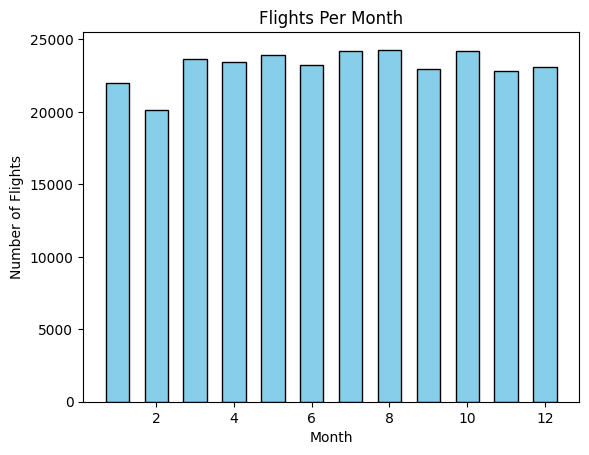

In [46]:
# Create vertical bar chart
plt.bar(df['month'], df['number_of_flights'], color='skyblue', edgecolor='black', width=0.6)

# Add titles and labels
plt.title('Flights Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Flights')

# Display the chart
plt.show()